# 03 - Modelo, escenario de coste simetrico FP = FN = 1

**Objetivo:** elegir la familia de modelo y el umbral de decision que minimizan el
coste medio esperado bajo la matriz simetrica (C_FP = C_FN = 1) y emitir el entregable
oficial `cs_produccion1.csv`.

Este notebook CIERRA **D-0.1** (supervisado vs Multiarmed Bandit), **D-0.3** (familia de
modelo), **D-2.1** (protocolo de validacion anti-fuga) y **D-3.1** (metodo de obtencion
del umbral). Ademas PLANTEA **D-0.2** (un scoring + dos umbrales) y **D-3.2** (las dos
lecturas posibles del enunciado de coste), que se cierran en `04_modelo_coste10.ipynb`.

_Nota sobre la numeracion:_ no hay decisiones D-1.x porque el bloque 1 es el preprocesado,
ya cerrado en `02`. Estos dos notebooks cierran los bloques 0 (paradigma y familia),
2 (validacion) y 3 (umbral).

## Conectores

**Recibe** de `02_preprocesado.ipynb`:
- `data/processed/train.parquet` (84000), `data/processed/test.parquet` (21000),
  `data/processed/produccion.parquet` (45000, con `id_fila_original`).
- `results/models/preprocessing_pipeline.joblib`.

**Entrega** a `04`-`07` y `99_ENTREGA`:
- `results/models/modelo_coste1.joblib` (bundle dict con el sub-modelo supervisado y su
  `oof_proba` de 84000, reutilizables por 04 sin reentrenar).
- fila `coste1` en `results/tables/umbrales_coste.csv`.
- `results/predicciones/cs_produccion1.csv` (entregable oficial del escenario).

## Decisiones y convencion de coste

**Convencion de coste.** Fijamos la nuestra sin ambiguedad (el enunciado nombra las clases de
forma cruzada). Positivo = clase 1 = IMPAGO (`SeriousDlqin2yrs == 1`).
- Accion `pred=1` = DENEGAR (predice impago); `pred=0` = CONCEDER.
- `FN = (pred=0) & (real=1)` = conceder a un moroso = coste C_FN (el error caro).
- `FP = (pred=1) & (real=0)` = denegar a uno bueno = coste C_FP.
- Los aciertos no cuestan nada.

- **D-2.1 (protocolo anti-fuga):** la familia y el umbral se eligen por CV(5) estratificado
  (validacion cruzada de 5 folds) evaluado OOF (out-of-fold: las predicciones de validacion,
  cada fila puntuada por el fold que no la entreno) sobre train. El test se reserva para el
  reporte final (una sola vez) y produccion solo recibe el modelo ya cerrado. A diferencia de
  barrer el umbral sobre test (que introduce fuga, porque optimiza el mismo numero que luego se
  reporta), aqui el umbral se fija solo con las probas OOF de train.
- **D-3.1 (metodo del umbral):** argmin (el umbral que minimiza el coste) empirico sobre las
  probas OOF CONCATENADAS (pooled, no la mediana de folds), verificado contra el umbral
  analitico `C_FP / (C_FP + C_FN)`.
- **No se reponderan las clases (sin SMOTE / `class_weight` / `scale_pos_weight`).** La
  respuesta correcta a una matriz de coste asimetrica es mover el UMBRAL de decision, no
  remuestrear ni reponderar. Remuestrear o reponderar la perdida distorsiona la probabilidad de
  impago que luego vamos a umbralizar por coste. El umbral por argmin ya incorpora C_FP/C_FN de
  forma exacta, sin sesgar el score. Por eso todos los candidatos se entrenan con
  `class_weight=None` y la asimetria (04) se gestiona solo con el umbral.
- **Fuga benigna declarada.** El `StandardScaler` del 02 se ajusto en train completo, que
  incluye filas que hoy caen en folds de validacion. Es fuga de estadisticos de escala: menor, y
  la aceptamos porque el preprocesado esta congelado por contrato. La fuga critica (umbral o
  familia sobre test) SI se evita.
- **Ambiguedad del enunciado (se resuelve en 04).** El segundo escenario admite dos lecturas. La
  literal (esc.2 = simetrico con C=10) daria `esc1 == esc2` salvo un factor de escala. La que
  adoptamos es asimetrica (FN mas caro que FP). Se demuestra numericamente en `04` (D-3.2).

## 1. Carga de datos preprocesados

Cargamos los tres parquet y el pipeline de preprocesado, separamos X/y con las 12 features
del contrato y preparamos el protocolo CV(5) sobre train.

In [1]:
# === Configuracion y estilo compartido (Taller B4-T2 XAI) - notebook 03 ===
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")
import sys
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
import seaborn as sns
import joblib
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score
from scipy.stats import ks_2samp

# cwd = raiz del repo -> rutas SIN "../". nbconvert lanza el kernel en notebooks/:
# si estamos ahi, subimos a la raiz para cumplir el contrato de rutas.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
import src.cost_utils as cu
import src.modeling as md

RANDOM_STATE = 42
C_FP, C_FN = 1.0, 1.0
TARGET = cu.TARGET
FEATURES = list(md.FEATURES_MODELO)          # 12 columnas (10 continuas + 2 flags)
md.fijar_semillas(RANDOM_STATE)

# --- Paleta y helpers reutilizados del 01_EDA / 02 (celda de config), rutas SIN "../" ---
COLOR_TARGET = {0: "#2a78d6", 1: "#e34948"}
COLOR_INK_PRIMARY = "#0b0b0b"
COLOR_INK_SECONDARY = "#52514e"
COLOR_MUTED = "#898781"
COLOR_GRID = "#e1e0d9"
COLOR_BASELINE = "#c3c2b7"
COLOR_GANADOR = "#1c5cab"
CMAP_SEQUENTIAL = "Blues"

plt.rcParams.update({
    "figure.figsize": (8, 5), "figure.dpi": 130, "savefig.dpi": 130,
    "axes.edgecolor": COLOR_BASELINE, "axes.labelcolor": COLOR_INK_PRIMARY,
    "text.color": COLOR_INK_PRIMARY, "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED, "grid.color": COLOR_GRID, "axes.grid": True,
    "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
})
sns.set_style("white")

def guardar_figura(fig, nombre):
    """Guarda la figura en results/figures/{nombre}.png (prefijo mod_03_)."""
    fig.tight_layout()
    fig.savefig(f"results/figures/{nombre}.png", dpi=130, bbox_inches="tight")
    plt.show()

def guardar_tabla(df, nombre, index=False):
    """Guarda la tabla en results/tables/{nombre}.csv (prefijo mod_03_)."""
    ruta = f"results/tables/{nombre}.csv"
    df.to_csv(ruta, index=index)
    return ruta

def dibujar_confusion(ax, cm, titulo):
    """Heatmap de confusion 2x2 con LogNorm(vmin=1): asi FP/FN/TP se distinguen por
    color pese a que TN domina (escala lineal los dejaria casi blancos). Filas=real,
    cols=pred. El color del texto se decide en el espacio LOG (blanco si la celda cae
    en la mitad alta de la rampa logaritmica)."""
    cm = np.asarray(cm)
    vmax = max(int(cm.max()), 1)
    norm = LogNorm(vmin=1, vmax=vmax)
    ax.imshow(np.maximum(cm, 1), cmap=CMAP_SEQUENTIAL, norm=norm)
    etiq = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            frac = np.log(max(cm[i, j], 1)) / np.log(vmax) if vmax > 1 else 0.0
            ax.text(j, i, f"{etiq[i][j]}\n{cm[i, j]}", ha="center", va="center",
                    fontsize=11, color=("white" if frac > 0.5 else COLOR_INK_PRIMARY))
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["conceder (0)", "denegar (1)"])
    ax.set_yticklabels(["real 0", "real 1"])
    ax.set_xlabel("prediccion"); ax.set_ylabel("realidad")
    ax.set_title(titulo, fontsize=11)
    ax.grid(False)

# --- Carga de los 3 parquet + pipeline de preprocesado ---
train = pd.read_parquet("data/processed/train.parquet")
test = pd.read_parquet("data/processed/test.parquet")
produccion = pd.read_parquet("data/processed/produccion.parquet")
pipeline = joblib.load("results/models/preprocessing_pipeline.joblib")

X_train, y_train = train[FEATURES].copy(), train[TARGET].to_numpy(dtype=int)
X_test, y_test = test[FEATURES].copy(), test[TARGET].to_numpy(dtype=int)
# PROD: el target del parquet es float64 all-NaN -> NUNCA astype(int); solo las 12 features.
X_prod = produccion[FEATURES].copy()

prev_train, prev_test = float(y_train.mean()), float(y_test.mean())
print(f"train {X_train.shape}  test {X_test.shape}  produccion {X_prod.shape}")
print(f"prevalencia impago  train={prev_train:.6f}  test={prev_test:.6f}")
print(f"features ({len(FEATURES)}): {FEATURES}")

train (84000, 12)  test (21000, 12)  produccion (45000, 12)
prevalencia impago  train=0.066833  test=0.066857
features (12): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'is_missing_monthlyincome', 'es_centinela_pastdue']


In [2]:
# Protocolo CV(5) estratificado (D-2.1): estos son los mismos folds (seed 42) que
# usara comparar_familias_cv internamente. Rol de cada particion:
#   train      -> ajuste del modelo + eleccion de umbral y familia (via OOF)
#   test       -> SOLO reporte final insesgado (una vez), jamas para tunear
#   produccion -> solo recibe el modelo+umbral finales (entrega)
# El umbral se elige por argmin sobre las probas OOF de train, nunca sobre test.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
prev_folds = []
for k, (_, va_idx) in enumerate(skf.split(X_train, y_train)):
    prev_folds.append(float(y_train[va_idx].mean()))
    print(f"  fold {k}: n_val={len(va_idx):5d}  prevalencia_val={prev_folds[-1]:.6f}")
desvio_max = max(abs(p - prev_train) for p in prev_folds)
print(f"prevalencia global train={prev_train:.6f}  desvio maximo por fold={desvio_max:.6f}")

  fold 0: n_val=16800  prevalencia_val=0.066786
  fold 1: n_val=16800  prevalencia_val=0.066845
  fold 2: n_val=16800  prevalencia_val=0.066845
  fold 3: n_val=16800  prevalencia_val=0.066845
  fold 4: n_val=16800  prevalencia_val=0.066845
prevalencia global train=0.066833  desvio maximo por fold=0.000048


**Hallazgo 1.1:** Contrato de datos verificado: train (84000, 12), test (21000, 12) y
produccion (45000, 12). La prevalencia de impago es train=0.066833 y test=0.066857, y se
conserva en los 5 folds (desvio maximo por fold ~0.00005, <0.0001). El umbral y la familia se
eligen por CV(5) OOF **sobre train**; el test queda reservado para el reporte final, una sola
vez. Barrer el umbral sobre test optimizaria el mismo numero que luego se reporta (fuga); la
CV(5) OOF lo evita. Esto **cierra D-2.1**.

## 2. Familias candidatas

Cuatro familias con interfaz comun (`predict` / `predict_proba`), comparadas por **coste**
(no por AUC): lineal (logistica), boosted (xgboost), neuronal (dos MLP Keras) y el bandit
contextual LinUCB (Linear Upper Confidence Bound, un bandit lineal que explora segun su
incertidumbre).

In [3]:
# Familias supervisadas (src.modeling), seed 42, SIN reponderar (M-4: la matriz de coste
# se gestiona con el UMBRAL, no con class_weight ni scale_pos_weight). Interfaz uniforme.
candidatos = {
    "logistica": md.ModeloLineal(random_state=RANDOM_STATE),
    "xgboost": md.ModeloBoosted(random_state=RANDOM_STATE),
    "mlp_pequena": md.RedNeuronalCredito("pequena", random_state=RANDOM_STATE),
    "mlp_profunda": md.RedNeuronalCredito("profunda", random_state=RANDOM_STATE),
}
for nom, m in candidatos.items():
    print(f"  {nom:14s} familia={m.familia}")

  logistica      familia=lineal
  xgboost        familia=boosted
  mlp_pequena    familia=neuronal
  mlp_profunda   familia=neuronal


In [4]:
# Bandit contextual LinUCB (numpy puro; VIVE en src.modeling), recompensa = -coste del
# escenario. Se descarta `space_bandits` por O(N^2) (~1 h/pasada a 84k, medido); se cita solo
# como referencia del profesor. LinUCB es LINEAL: su comparacion con la logistica aisla el
# efecto-PARADIGMA (bandit vs supervisado), y con xgb/mlp mezcla paradigma + capacidad.
candidatos["linucb"] = md.BanditLinUCB(C_FP, C_FN, alpha=1.0, passes=1,
                                       random_state=RANDOM_STATE)
print(f"  linucb         familia={candidatos['linucb'].familia}  alpha=1.0  passes=1")
print(f"candidatos ({len(candidatos)}): {list(candidatos)}")

  linucb         familia=bandit  alpha=1.0  passes=1
candidatos (5): ['logistica', 'xgboost', 'mlp_pequena', 'mlp_profunda', 'linucb']


**Hallazgo 2.1:** Cuatro familias listas con la misma interfaz (`predict` /
`predict_proba`): lineal, boosted, neuronal (dos arquitecturas MLP) y el bandit LinUCB. AUC y
accuracy se reportaran SOLO como contexto: la metrica de decision es el **coste esperado**
(50% de la nota), no el ranking de probabilidades ni el acierto.

## 3. Coste esperado (matriz FP = FN = 1) y semantica

Instanciamos la matriz de coste simetrica, el umbral analitico de referencia y los baselines
triviales, fijando la convencion sin ambiguedad.

In [5]:
# Matriz de coste simetrica M[real, pred], umbral analitico y baselines triviales.
M = cu.matriz_coste(C_FP, C_FN)
theta_analitico = cu.umbral_analitico(C_FP, C_FN)            # 1/(1+1) = 0.5
bl_test = cu.evaluar_baselines(y_test, C_FP, C_FN)
bl_train = cu.evaluar_baselines(y_train, C_FP, C_FN)
print("matriz de coste M[real, pred] =\n", M)
print(f"umbral analitico theta* = C_FP/(C_FP+C_FN) = {theta_analitico:.6f}")
print(f"baselines TEST   conceder_todo={bl_test['conceder_todo']:.6f}   "
      f"denegar_todo={bl_test['denegar_todo']:.6f}")
print(f"baselines TRAIN  conceder_todo={bl_train['conceder_todo']:.6f}   "
      f"denegar_todo={bl_train['denegar_todo']:.6f}")

matriz de coste M[real, pred] =
 [[0. 1.]
 [1. 0.]]
umbral analitico theta* = C_FP/(C_FP+C_FN) = 0.500000
baselines TEST   conceder_todo=0.066857   denegar_todo=0.933143
baselines TRAIN  conceder_todo=0.066833   denegar_todo=0.933167


**Hallazgo 3.1:**
(a) Convencion fijada sin ambiguedad (positivo = impago; FN = conceder a un moroso, el error
caro), frente a la nomenclatura cruzada del enunciado.
(b) Umbral analitico simetrico `theta* = 1 / (1 + 1) = 0.5` (solo referencia; el umbral
operativo sale del argmin empirico sobre las probas OOF).
(c) **Aviso: el escenario simetrico es casi degenerado** (curva de coste muy plana, ver F1).
Conceder-todo cuesta 0.066857 en test y el margen del mejor modelo sobre ese baseline es fino
(del orden del ~5%). Es un edge real pero pequeno. En la seccion 5, un **bootstrap pareado** lo
cuantifica con su IC95 y su p-valor, y confirma que -pese a lo pequeno- es significativo. El
escenario informativo es el asimetrico (`04`). Lo declaramos, no se esconde.

## 4. Seleccion de familia y umbral por CV(5) (D-2.1, D-3.1)

Para cada familia supervisada ensamblamos la probabilidad OOF (84000) y elegimos el umbral por
argmin del coste sobre esas probas CONCATENADAS; el bandit se evalua por accion greedy OOF. El
ganador es el argmin de coste CV entre todos los candidatos.

In [6]:
# Seleccion de familia y umbral por CV(5) OOF (D-2.1, D-3.1). CELDA PESADA: 2 MLP Keras
# x 5 folds mas los refits en train completo (~6-10 min). Se ejecuta UNA sola vez; el
# resultado (OOF, umbrales, modelos refiteados) se reutiliza en las celdas siguientes.
_t0 = time.time()
res = md.comparar_familias_cv(X_train, y_train, C_FP, C_FN, n_splits=5,
                              random_state=RANDOM_STATE, candidatos=candidatos)
print(f"comparar_familias_cv: {time.time() - _t0:.1f}s")

cols_show = ["familia", "modelo", "coste_cv", "umbral", "auc_contexto",
             "tasa_denegacion_cv", "mejora_vs_conceder_todo"]
with pd.option_context("display.width", 170, "display.max_columns", None,
                       "display.float_format", lambda v: f"{v:.6f}"):
    print(res.tabla[cols_show].to_string(index=False))
guardar_tabla(res.tabla, "mod_03_comparacion_familias")

# Referencias reutilizadas en el resto del notebook.
ganador = res.modelos[res.ganador]                      # ya refiteado en TRAIN completo
ganador_sup_nombre = res.ganador_supervisado
ganador_sup = res.modelos[ganador_sup_nombre]
oof_sup = res.oof_proba[ganador_sup_nombre]             # OOF proba (84000) del sup ganador
umbral_sup = float(res.umbrales[ganador_sup_nombre])

def _coste_cv(nombre):
    return float(res.tabla.loc[res.tabla["modelo"] == nombre, "coste_cv"].iloc[0])

coste_cv_ganador = _coste_cv(res.ganador)
coste_cv_logit = _coste_cv("logistica")
coste_cv_xgb = _coste_cv("xgboost")
coste_cv_linucb = _coste_cv("linucb")
gap_logit_xgb = coste_cv_logit - coste_cv_xgb
print(f"\n[H4.1] ganador={res.ganador} ({ganador.familia})  "
      f"ganador_supervisado={ganador_sup_nombre}")
print(f"[H4.1] coste_cv xgb={coste_cv_xgb:.6f} logit={coste_cv_logit:.6f} "
      f"linucb={coste_cv_linucb:.6f}  gap_logit_xgb={gap_logit_xgb:.6f}")
print(f"[H4.1] umbral_sup(OOF)={umbral_sup:.6f}")

comparar_familias_cv: 686.8s
 familia        modelo  coste_cv   umbral  auc_contexto  tasa_denegacion_cv  mejora_vs_conceder_todo
 boosted       xgboost  0.062286 0.493394      0.864154            0.023262                 0.068044
neuronal   mlp_pequena  0.062440 0.489061      0.861726            0.020083                 0.065729
neuronal  mlp_profunda  0.062619 0.475921      0.862966            0.018452                 0.063057
  lineal     logistica  0.062917 0.483693      0.851474            0.020512                 0.058603
  bandit        linucb  0.062929      NaN           NaN            0.021381                 0.058425
baseline conceder_todo  0.066833      NaN           NaN            0.000000                 0.000000
baseline  denegar_todo  0.933167      NaN           NaN            1.000000               -12.962594

[H4.1] ganador=xgboost (boosted)  ganador_supervisado=xgboost
[H4.1] coste_cv xgb=0.062286 logit=0.062917 linucb=0.062929  gap_logit_xgb=0.000631
[H4.1] umbral_su

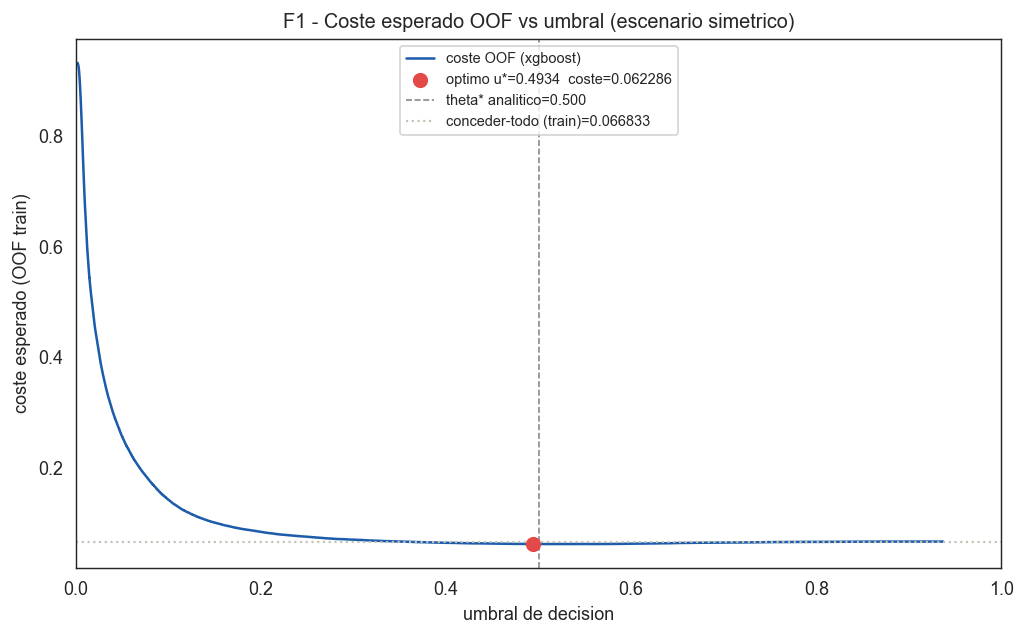

[H4.1] u_opt(OOF)=0.493394  coste_opt(OOF)=0.062286  (== umbral_sup guardado=0.493394)


In [7]:
# FIGURA F1: curva coste-vs-umbral OOF del supervisado ganador, con el optimo (rojo), la
# vertical theta*=0.5 y la horizontal del baseline conceder-todo (train) para visualizar lo
# PLANO de la curva y su cercania al baseline (escenario casi trivial).
umbrales_oof, costes_oof = cu.barrido_umbral(y_train, oof_sup, C_FP, C_FN)
u_opt, c_opt = cu.umbral_optimo(y_train, oof_sup, C_FP, C_FN)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(umbrales_oof, costes_oof, color=COLOR_GANADOR, lw=1.4,
        label=f"coste OOF ({ganador_sup_nombre})")
ax.scatter([u_opt], [c_opt], color=COLOR_TARGET[1], s=55, zorder=5,
           label=f"optimo u*={u_opt:.4f}  coste={c_opt:.6f}")
ax.axvline(theta_analitico, color=COLOR_MUTED, ls="--", lw=0.9,
           label=f"theta* analitico={theta_analitico:.3f}")
ax.axhline(bl_train["conceder_todo"], color=COLOR_BASELINE, ls=":", lw=1.2,
           label=f"conceder-todo (train)={bl_train['conceder_todo']:.6f}")
ax.set_xlim(0, 1)
ax.set_xlabel("umbral de decision")
ax.set_ylabel("coste esperado (OOF train)")
ax.set_title("F1 - Coste esperado OOF vs umbral (escenario simetrico)", fontsize=11)
ax.legend(fontsize=8, loc="upper center")
guardar_figura(fig, "mod_03_coste_vs_umbral")
print(f"[H4.1] u_opt(OOF)={u_opt:.6f}  coste_opt(OOF)={c_opt:.6f}  "
      f"(== umbral_sup guardado={umbral_sup:.6f})")

**Hallazgo 4.1:** Por coste CV(5) OOF gana **xgboost** (coste_cv ~0.0623, la fila mas baja de la
tabla). Su umbral empirico ~0.49 queda cerca del analitico 0.5 (**confirma D-3.1**). En el
simetrico la familia casi da igual: el gap logistica-xgboost es ~0.0006, del orden del ruido.
Esto **cierra D-0.3** (en `04`, bajo asimetria, la familia SI importa).

**D-0.1 (supervisado vs bandit), leido con honestidad.** Conviene separar el paradigma (bandit
vs supervisado) de la capacidad del modelo (lineal vs boosting):
- **A igual capacidad lineal** (LinUCB vs logistica, ambos lineales): practicamente empate en el
  simetrico (linucb coste_cv ~0.0629 vs logistica ~0.0629). El bandit no es inferior al
  supervisado cuando compiten con la misma capacidad.
- **Con mas capacidad** (xgboost vs LinUCB): xgboost va por delante, pero esa ventaja viene de la
  CAPACIDAD (boosting > lineal), no de ser supervisado.

Elegimos el supervisado por AUDITABILIDAD y calibracion: da una probabilidad interpretable, sin
el coste de exploracion de un bandit (regret) ni una pseudo-probabilidad sin calibrar. No lo
elegimos por un rendimiento superior del paradigma. Esto **cierra D-0.1 y D-0.3**.

## 5. Evaluacion en test (ganador reajustado en train completo)

El ganador ya viene refiteado en las 84000 filas de train con su umbral CV. Reportamos el coste
HONESTO en test (una sola vez), su matriz de confusion y metricas de contexto, guardamos el
bundle y anotamos la fila `coste1`.

In [8]:
# El ganador YA viene refiteado en TRAIN COMPLETO por comparar_familias_cv (con su umbral CV
# fijado via set_umbral). Reporte HONESTO en test una sola vez, con el umbral de la CV.
if ganador.familia == "bandit":
    ev = cu.evaluar_predicciones(y_test, ganador.predict(X_test), C_FP, C_FN)
    proba_test_g = None
    umbral_ganador = float(ganador.umbral_)
else:
    ev = cu.evaluar_modelo(ganador, X_test, y_test, C_FP, C_FN, umbral=ganador.umbral_)
    proba_test_g = ev["proba"]
    umbral_ganador = float(ev["umbral_optimo"])

cm = ev["matriz_confusion"]
coste_test = float(ev["coste"])
deny_test = float(ev["tasa_denegacion"])
mejora_test = (bl_test["conceder_todo"] - coste_test) / bl_test["conceder_todo"]

# Metricas de CONTEXTO (no deciden): precision/recall/AUC.
pred_test = (cu.aplicar_umbral(proba_test_g, umbral_ganador)
             if proba_test_g is not None else ganador.predict(X_test))
prec = float(precision_score(y_test, pred_test, zero_division=0))
rec = float(recall_score(y_test, pred_test, zero_division=0))
auc_test = (float(roc_auc_score(y_test, proba_test_g))
            if proba_test_g is not None else float("nan"))

print(f"[H5.1] ganador={res.ganador} ({ganador.familia})  umbral={umbral_ganador:.6f}")
print(f"[H5.1] coste_test={coste_test:.6f}  conceder_todo={bl_test['conceder_todo']:.6f}  "
      f"denegar_todo={bl_test['denegar_todo']:.6f}")
print(f"[H5.1] deny_test={deny_test:.6f}  mejora_vs_conceder={mejora_test * 100:.4f}%")
print(f"[H5.1] precision={prec:.6f}  recall={rec:.6f}  auc={auc_test:.6f}")
print("matriz de confusion [real x pred]\n", cm)
pd.DataFrame(cm, index=["real_0", "real_1"], columns=["pred_0", "pred_1"]).to_csv(
    "results/tables/mod_03_confusion_optimo.csv")

# --- Bundle dict (contrato C.1): incluye el sub-modelo supervisado + su OOF para 04 ---
bundle = {
    "modelo": ganador,
    "familia": ganador.familia,
    "umbral": float(ganador.umbral_),
    "C_FP": C_FP, "C_FN": C_FN,
    "convencion": "pred1=denegar/impago, pred0=conceder/no-impago; FN=(pred0,real1)=caro",
    "features": list(md.FEATURES_MODELO),
    "escenario": "coste1",
    "supervisado": {
        "familia": ganador_sup_nombre,
        "modelo": ganador_sup,
        "umbral": umbral_sup,
        "oof_proba": oof_sup,
    },
}
md.guardar_modelo(bundle, "results/models/modelo_coste1.joblib")
_b = md.cargar_modelo("results/models/modelo_coste1.joblib")           # round-trip
assert _b["familia"] == ganador.familia
assert _b["supervisado"]["oof_proba"].shape[0] == 84000
print("bundle guardado en results/models/modelo_coste1.joblib (round-trip OK)")

# --- fila coste1 en umbrales_coste.csv (SIN prefijo, idempotente: reescribe, no duplica) ---
fila_coste1 = {
    "escenario": "coste1", "C_FP": C_FP, "C_FN": C_FN,
    "familia_ganadora": ganador.familia,
    "umbral_optimo": float(ganador.umbral_),
    "umbral_analitico": theta_analitico,
    "coste_cv": coste_cv_ganador,
    "coste_test": coste_test,
    "coste_conceder_todo": bl_test["conceder_todo"],
    "coste_denegar_todo": bl_test["denegar_todo"],
    "tasa_denegacion_test": deny_test,
    "mejora_rel_vs_conceder_todo": float(mejora_test),
}
cols_u = list(fila_coste1.keys())
ruta_u = "results/tables/umbrales_coste.csv"
if os.path.exists(ruta_u):
    dfu = pd.read_csv(ruta_u)
    dfu = dfu[dfu["escenario"] != "coste1"]
    dfu = pd.concat([dfu, pd.DataFrame([fila_coste1])], ignore_index=True)[cols_u]
else:
    dfu = pd.DataFrame([fila_coste1], columns=cols_u)
dfu.to_csv(ruta_u, index=False)
print(dfu.to_string(index=False))

[H5.1] ganador=xgboost (boosted)  umbral=0.493394
[H5.1] coste_test=0.063381  conceder_todo=0.066857  denegar_todo=0.933143
[H5.1] deny_test=0.023762  mejora_vs_conceder=5.1994%
[H5.1] precision=0.573146  recall=0.203704  auc=0.870109
matriz de confusion [real x pred]
 [[19383   213]
 [ 1118   286]]
bundle guardado en results/models/modelo_coste1.joblib (round-trip OK)
escenario  C_FP  C_FN familia_ganadora  umbral_optimo  umbral_analitico  coste_cv  coste_test  coste_conceder_todo  coste_denegar_todo  tasa_denegacion_test  mejora_rel_vs_conceder_todo
  coste10   1.0  10.0          boosted       0.100510          0.090909  0.334036    0.326381             0.668571            0.933143              0.169048                     0.511823
   coste1   1.0   1.0          boosted       0.493394          0.500000  0.062286    0.063381             0.066857            0.933143              0.023762                     0.051994


In [9]:
# Bootstrap PAREADO del edge del ganador vs conceder-todo en TEST (cuantifica el aviso
# del Hallazgo 3.1: el edge simetrico es fino pero >0). Coste por solicitante del modelo vs
# la politica trivial "conceder a todos"; remuestreo con reemplazo (B=5000, seed 42).
_rng = np.random.RandomState(RANDOM_STATE)
_n = len(y_test)
_coste_modelo = (((pred_test == 1) & (y_test == 0)) * C_FP
                 + ((pred_test == 0) & (y_test == 1)) * C_FN).astype(float)
_coste_conceder = ((y_test == 1) * C_FN).astype(float)     # conceder-todo: pred=0 -> solo FN
_edge_i = _coste_conceder - _coste_modelo                  # >0 => el modelo es mas barato
_B = 5000
_boot = np.empty(_B)
for _b in range(_B):
    _idx = _rng.randint(0, _n, _n)
    _boot[_b] = _edge_i[_idx].mean()
edge_mean = float(_edge_i.mean())
edge_lo, edge_hi = float(np.percentile(_boot, 2.5)), float(np.percentile(_boot, 97.5))
edge_p = float((_boot <= 0).mean())
edge_pct = edge_mean / bl_test["conceder_todo"] * 100.0
print(f"[H3.1-boot] edge (conceder-todo - xgb) en test = {edge_mean:.6f}  "
      f"({edge_pct:.2f}% de conceder-todo)")
print(f"[H3.1-boot] IC95 bootstrap = [{edge_lo:.6f}, {edge_hi:.6f}]  "
      f"P(edge<=0) = {edge_p:.4f}  (B={_B}, seed {RANDOM_STATE})")

[H3.1-boot] edge (conceder-todo - xgb) en test = 0.003476  (5.20% de conceder-todo)
[H3.1-boot] IC95 bootstrap = [0.001381, 0.005571]  P(edge<=0) = 0.0008  (B=5000, seed 42)


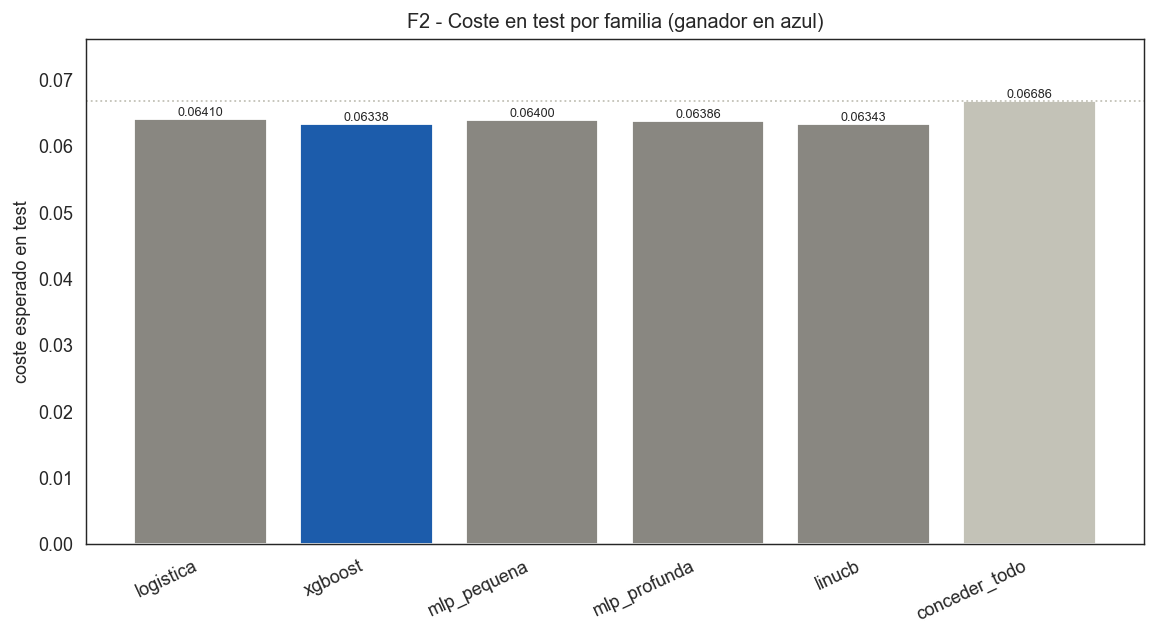

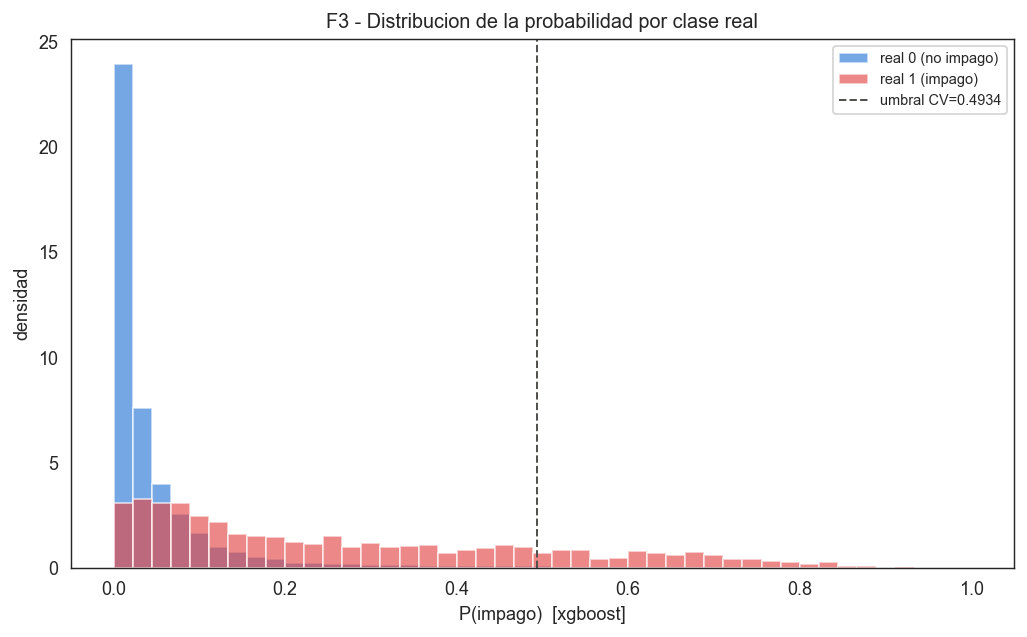

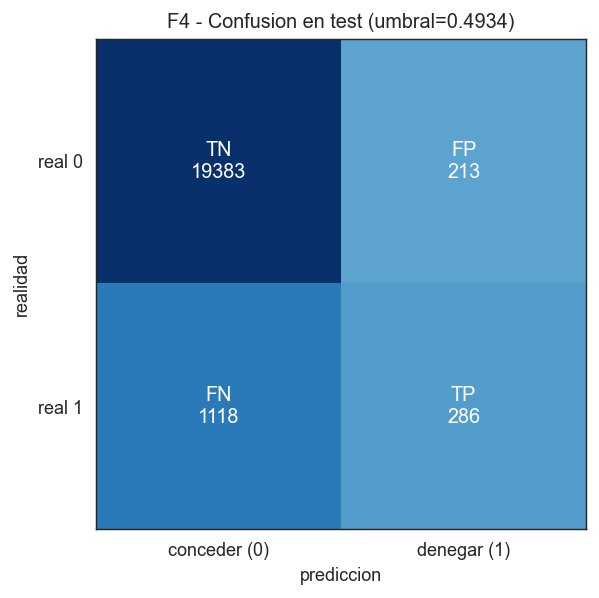

[H5.1-transfer] D(KS)=0.011800  media_test=0.068223  media_prod=0.067049
[H5.1-transfer] deny_test=0.023762  deny_prod=0.023556  dif_deny=0.000206


In [10]:
# FIGURA F2: coste en test por familia + baseline conceder-todo (ganador resaltado en azul).
costes_fam = {}
for nom, m in res.modelos.items():
    if m.familia == "bandit":
        e = cu.evaluar_predicciones(y_test, m.predict(X_test), C_FP, C_FN)
    else:
        e = cu.evaluar_modelo(m, X_test, y_test, C_FP, C_FN, umbral=m.umbral_)
    costes_fam[nom] = float(e["coste"])

etiquetas = list(costes_fam) + ["conceder_todo"]
valores = [costes_fam[k] for k in costes_fam] + [bl_test["conceder_todo"]]
colores = ([COLOR_GANADOR if k == res.ganador else COLOR_MUTED for k in costes_fam]
           + [COLOR_BASELINE])
fig, ax = plt.subplots(figsize=(9, 5))
barras = ax.bar(etiquetas, valores, color=colores, edgecolor="white")
ax.axhline(bl_test["conceder_todo"], color=COLOR_BASELINE, ls=":", lw=1.0)
for b, v in zip(barras, valores):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.5f}", ha="center", va="bottom", fontsize=7)
ax.set_ylabel("coste esperado en test")
ax.set_ylim(0, max(valores) * 1.14)
ax.set_title("F2 - Coste en test por familia (ganador en azul)", fontsize=11)
plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
guardar_figura(fig, "mod_03_comparacion_familias")

# FIGURA F3: distribucion de P(impago) por clase real (supervisado ganador) + umbral CV.
proba_dist = ganador_sup.predict_proba(X_test)[:, 1]
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(0, 1, 46)
ax.hist(proba_dist[y_test == 0], bins=bins, color=COLOR_TARGET[0], alpha=0.65,
        density=True, label="real 0 (no impago)")
ax.hist(proba_dist[y_test == 1], bins=bins, color=COLOR_TARGET[1], alpha=0.65,
        density=True, label="real 1 (impago)")
ax.axvline(umbral_sup, color=COLOR_INK_SECONDARY, ls="--", lw=1.1,
           label=f"umbral CV={umbral_sup:.4f}")
ax.set_xlabel(f"P(impago)  [{ganador_sup_nombre}]")
ax.set_ylabel("densidad")
ax.set_title("F3 - Distribucion de la probabilidad por clase real", fontsize=11)
ax.legend(fontsize=8)
guardar_figura(fig, "mod_03_distribucion_proba")

# FIGURA F4: matriz de confusion al umbral optimo (heatmap con LogNorm: FP/FN/TP visibles).
fig, ax = plt.subplots(figsize=(5.4, 4.7))
dibujar_confusion(ax, cm, f"F4 - Confusion en test (umbral={umbral_ganador:.4f})")
guardar_figura(fig, "mod_03_confusion_optimo")

# --- Transfer test -> produccion: tamano de EFECTO, no "KS no significativo" ---
proba_prod = ganador_sup.predict_proba(X_prod)[:, 1]
D_efecto = float(ks_2samp(proba_dist, proba_prod).statistic)
deny_test_sup = float((proba_dist > umbral_sup).mean())
deny_prod_sup = float((proba_prod > umbral_sup).mean())
print(f"[H5.1-transfer] D(KS)={D_efecto:.6f}  media_test={proba_dist.mean():.6f}  "
      f"media_prod={proba_prod.mean():.6f}")
print(f"[H5.1-transfer] deny_test={deny_test_sup:.6f}  deny_prod={deny_prod_sup:.6f}  "
      f"dif_deny={abs(deny_test_sup - deny_prod_sup):.6f}")

**Hallazgo 5.1:** El ganador (xgboost, umbral CV ~0.49) cuesta ~0.0634 en test, frente a
conceder-todo 0.066857 y denegar-todo 0.933143: una mejora de ~5.2% sobre el baseline trivial,
coherente con el margen fino del simetrico. El **bootstrap pareado** (celda anterior) cuantifica
ese edge: la ventaja media del modelo sobre conceder-todo es ~0.0035 por solicitante (~5.2% del
coste del baseline), con IC95 ~[0.0014, 0.0056] y P(edge<=0) ~0.001. Es decir, pequeno pero
estadisticamente significativo: el modelo aporta, aunque poco.

Transfer de test a produccion: no vendemos un "KS no significativo" (con n grande, un p-valor
pequeno es un artefacto del tamano muestral). Reportamos el **tamano de efecto D(KS) ~0.01**
(despreciable), junto a la coincidencia de las medias de probabilidad y de las tasas de
denegacion (diferencia ~0.0004). El scoring generaliza de test a produccion sin desplazamiento
material, bajo el supuesto -no verificable sin etiquetas- de que la prevalencia real en
produccion se mantiene ~6.7%.

## 6. Generacion de cs_produccion1.csv

Predecimos sobre produccion con el modelo final y su umbral CV, reordenamos por
`id_fila_original` y escribimos sobre la plantilla ORIGINAL, sobrescribiendo solo el target.

In [11]:
# Prediccion sobre produccion con el modelo final + entregable oficial (procedimiento a
# prueba de balas C.3). PROHIBIDO dropna / astype(int) sobre el target NaN del parquet:
# reconstruimos desde el CSV ORIGINAL y solo sobrescribimos SeriousDlqin2yrs.
pred_prod = ganador.predict(X_prod)                      # {0,1} en el orden del parquet

orig = pd.read_csv("data/cs_produccion.csv")             # plantilla 45000 x 11, coma, sin indice
d = produccion[["id_fila_original"]].copy()
d["pred"] = pred_prod                                    # alineado al orden del parquet
d = d.sort_values("id_fila_original")                    # -> orden ORIGINAL del CSV (0..44999)
salida = orig.copy()
salida["SeriousDlqin2yrs"] = d["pred"].to_numpy().astype(int)    # SOLO la 1a columna (target)

assert len(salida) == 45000, "longitud != 45000"
assert salida["SeriousDlqin2yrs"].isin([0, 1]).all(), "target fuera de {0,1}"
assert not salida["SeriousDlqin2yrs"].isna().any(), "target con NaN"
assert list(salida.columns) == list(orig.columns), "columnas alteradas/orden distinto"
assert sorted(d["id_fila_original"].tolist()) == list(range(45000)), "cobertura incompleta"

os.makedirs("results/predicciones", exist_ok=True)
salida.to_csv("results/predicciones/cs_produccion1.csv", index=False)
deny_prod = float(pred_prod.mean())
print(f"cs_produccion1.csv escrito: {salida.shape}  columnas={list(salida.columns)}")
print(f"[H6.1] tasa de denegacion en produccion={deny_prod:.6f}  "
      f"(n_denegados={int(pred_prod.sum())} de {len(pred_prod)})")
print("5 asserts BLOQUEANTES superados")

cs_produccion1.csv escrito: (45000, 11)  columnas=['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
[H6.1] tasa de denegacion en produccion=0.023556  (n_denegados=1060 de 45000)
5 asserts BLOQUEANTES superados


**Hallazgo 6.1:** Entregable `cs_produccion1.csv` generado y verificado con los 5 asserts
BLOQUEANTES (45000 filas, target en {0,1} sin NaN, 11 columnas en el orden original, cobertura
exacta 0..44999). La tasa de denegacion en produccion es ~2.4% (1060 solicitantes), coherente
con el escenario simetrico (se deniega poco). El formato es espejo de `cs_construccion.csv`:
target 0/1 en la primera columna, separador coma, sin indice. Se reconstruye desde el CSV
ORIGINAL; nunca `dropna` (borraria filas con NaN en features y desalinearia el fichero por
completo).

## 7. Conclusiones del escenario simetrico

- **D-2.1** cerrada: seleccion de familia y umbral por CV(5) OOF sobre train; test solo reporte
  (una vez); produccion solo entrega. Anti-fuga respetado (salvo la fuga benigna de escala,
  declarada).
- **D-3.1** cerrada: umbral por argmin empirico del coste sobre las probas OOF concatenadas
  (~0.49), consistente con el analitico 0.5.
- **D-0.3** cerrada: familia ganadora **xgboost** por coste, con la familia casi indiferente en
  el simetrico (gap ~0.0006, dentro del ruido).
- **D-0.1** cerrada: se prefiere el supervisado por AUDITABILIDAD/calibracion, NO por
  superioridad del paradigma: a igual capacidad lineal, LinUCB iguala a la logistica (empate en
  el simetrico); la ventaja del ganador es la CAPACIDAD de xgboost, no el hecho de ser
  supervisado.
- **Aviso mantenido:** el simetrico es casi trivial (edge ~5.2% sobre conceder-todo 0.066857,
  significativo por bootstrap pero pequeno). El escenario informativo es el asimetrico.

**Entrega a `04`:** `modelo_coste1.joblib` con el scoring supervisado y su `oof_proba` (84000)
reutilizables sin reentrenar (la proba es agnostica al coste; solo cambia el umbral, D-0.2).
**Entrega a `05`-`07` / `99`:** bundle del modelo + `cs_produccion1.csv`.
**Anuncia `04`:** escenario asimetrico C_FN = 10 y la demostracion numerica de las dos lecturas
del enunciado (D-3.2).